## Trial 1 Analysis
Thursday, March 19

## Table of Contents

1. [Setup & Apparatus](#1-setup--apparatus)
2. [Part 1: Moisture Loss Characterisation](#2-part-1-moisture-loss-characterisation)
   - 2.1 Overview
   - 2.2 Method
   - 2.3 Data Loading
   - 2.4 Per-Group Summary Statistics
   - 2.5 Visualisation
   - 2.6 Pairwise t-Tests
   - 2.7 Summary of Significant Differences
   - 2.8 Heatmap of p-values
   - 2.9 One-Way ANOVA: Does Bake Time Drive Fracture Metrics?
3. [Part 2: Fracture Mechanics Analysis](#3-part-2-fracture-mechanics-analysis)
   - 3.1 Context: The Puffing Problem
   - 3.2 Derived Fracture Quantities
   - 3.3 Regression Results
   - 3.4 Reading ANOVA, CoV, and Regression Together
   - 3.5 Improvements for Trial 2
4. [Appendix: Sample Calculations](#a-appendix-sample-calculations)

## 1. Setup & Apparatus

We used a convection oven at 375°C to bake chips at a range of times. 85 chips were tested across 8 bake time groups (3, 3.5, 4, 4.5, 5.5, 6, 6.5, 7 min), with 10 chips per group. Each chip was weighed before and after baking to get moisture loss, then immediately tested on the ring-punch fracture apparatus.

> **Apparatus constants**: support ring radius R = 30 mm, punch radius r = 3 mm, nominal chip thickness t = 2 mm.

## 2. Part 1: Moisture Loss Characterisation

### 2.1 Overview

We wanted to determine whether **moisture loss differs significantly between baking time groups**.

Moisture loss is defined here as the fractional mass lost during baking:
$$\text{Moisture loss (\%)} = \frac{m_\text{initial} - m_\text{final}}{m_\text{initial}} \times 100$$


Eight baking times were tested: **3, 3.5, 4, 4.5, 5.5, 6, 6.5, and 7 minutes**.

### 2.2 Method

A **two-sample independent t-test** asks: given the means and variability of two groups, how likely is it that the observed difference in means occurred by chance if the groups were drawn from the same population? With 8 groups there are 28 pairwise comparisons. Running 28 tests at α = 0.05 means we expect false positives by chance. We therefore report both:
- **Raw p-value**: unadjusted test result
- **Bonferroni-corrected p-value**: raw × 28, capped at 1.0. A corrected p-value < 0.05 gives stronger evidence of a true difference.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from itertools import combinations

sns.set_theme(style='ticks', palette='colorblind')
plt.rcParams['figure.dpi'] = 120

### 2.2 Data Loading

In [3]:
df = pd.read_csv('fracture_energy_trial1.csv')

# Drop empty trailing rows
df = df.dropna(subset=['Bake time (min)', 'Moisture loss'])
df = df.rename(columns={
    'Bake time (min)': 'Bake_time',
    'Moisture loss':   'Moisture_loss',
})

# Convert moisture loss to percentage for readability
df['Moisture_loss_pct'] = df['Moisture_loss'] * 100

# Sort by bake time
df = df.sort_values('Bake_time').reset_index(drop=True)

bake_times = sorted(df['Bake_time'].unique())
print(f"Chips loaded: {len(df)}")
print(f"Bake times: {bake_times}")
df[['Trial', 'Bake_time', 'Initial mass (g)', 'Final mass (g)', 'dmass (g)', 'Moisture_loss_pct', 'FractureEnergy_J']].head(10)

Chips loaded: 74
Bake times: [np.float64(3.0), np.float64(3.5), np.float64(4.0), np.float64(4.5), np.float64(5.5), np.float64(6.0), np.float64(6.5), np.float64(7.0)]


,Trial,Bake_time,Initial mass (g),Final mass (g),dmass (g),Moisture_loss_pct,FractureEnergy_J
0,61.0,3.0,2.4,1.6,0.8,33.333333,0.014781
1,62.0,3.0,2.2,1.5,0.7,31.818182,0.022265
2,63.0,3.0,2.8,1.9,0.9,32.142857,0.012240
3,64.0,3.0,3.0,2.0,1.0,33.333333,0.055119
4,68.0,3.0,2.8,2.1,0.7,25.000000,0.034087
5,67.0,3.0,3.1,2.4,0.7,22.580645,0.025735
6,66.0,3.0,3.2,2.3,0.9,28.125000,0.046129
7,65.0,3.0,2.9,2.1,0.8,27.586207,0.042518
8,70.0,3.0,3.0,2.1,0.9,30.000000,0.047615
9,69.0,3.0,3.0,2.1,0.9,30.000000,0.015212


### 2.3 Per-Group Summary Statistics

Before running any tests, we characterise each bake time group individually. For each group we report the mean moisture loss, standard deviation, standard error, and 95% confidence interval on the mean.

In [4]:
rows = []
for bt in bake_times:
    grp = df.loc[df['Bake_time'] == bt, 'Moisture_loss_pct']
    n   = len(grp)
    mu  = grp.mean()
    sd  = grp.std(ddof=1)
    se  = sd / np.sqrt(n)
    t_crit = stats.t.ppf(0.975, df=n - 1)  # two-tailed 95%
    ci_lo  = mu - t_crit * se
    ci_hi  = mu + t_crit * se
    rows.append({
        'Bake time (min)': bt,
        'n': n,
        'Mean (%)': round(mu, 2),
        'SD (%)':   round(sd, 2),
        'SE (%)':   round(se, 3),
        '95% CI lower': round(ci_lo, 2),
        '95% CI upper': round(ci_hi, 2),
        'Min (%)':  round(grp.min() * 1, 2),
        'Max (%)':  round(grp.max() * 1, 2),
    })

summary = pd.DataFrame(rows).set_index('Bake time (min)')
summary

,n,Mean (%),SD (%),SE (%),95% CI lower,95% CI upper,Min (%),Max (%)
Bake time (min),,,,,,,,
3.0,10,29.39,3.59,1.134,26.83,31.96,22.58,33.33
3.5,10,25.66,5.23,1.655,21.91,29.40,16.67,34.48
4.0,4,29.51,3.15,1.574,24.50,34.51,25.00,32.26
4.5,10,32.31,2.99,0.945,30.18,34.45,27.59,37.04
5.5,10,34.05,2.88,0.910,31.99,36.11,30.00,39.29
6.0,10,33.17,4.59,1.452,29.88,36.45,26.92,41.38
6.5,10,31.41,5.12,1.619,27.75,35.07,22.22,37.50
7.0,10,32.88,4.80,1.519,29.44,36.32,25.00,39.29


**Comments**: The SD column tells you how variable moisture loss is within a bake time group. If two groups have means that are close together relative to their SDs, a t-test is unlikely to find a significant difference there is  too much overlap. The 95% CI columns show the plausible range for each group's true mean; overlapping CIs are a strong visual signal that a t-test will not be significant.

### 2.4 Visualisation

C:\Users\shere\AppData\Local\Temp\ipykernel_25448\3801576670.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Bake_time', y='Moisture_loss_pct',


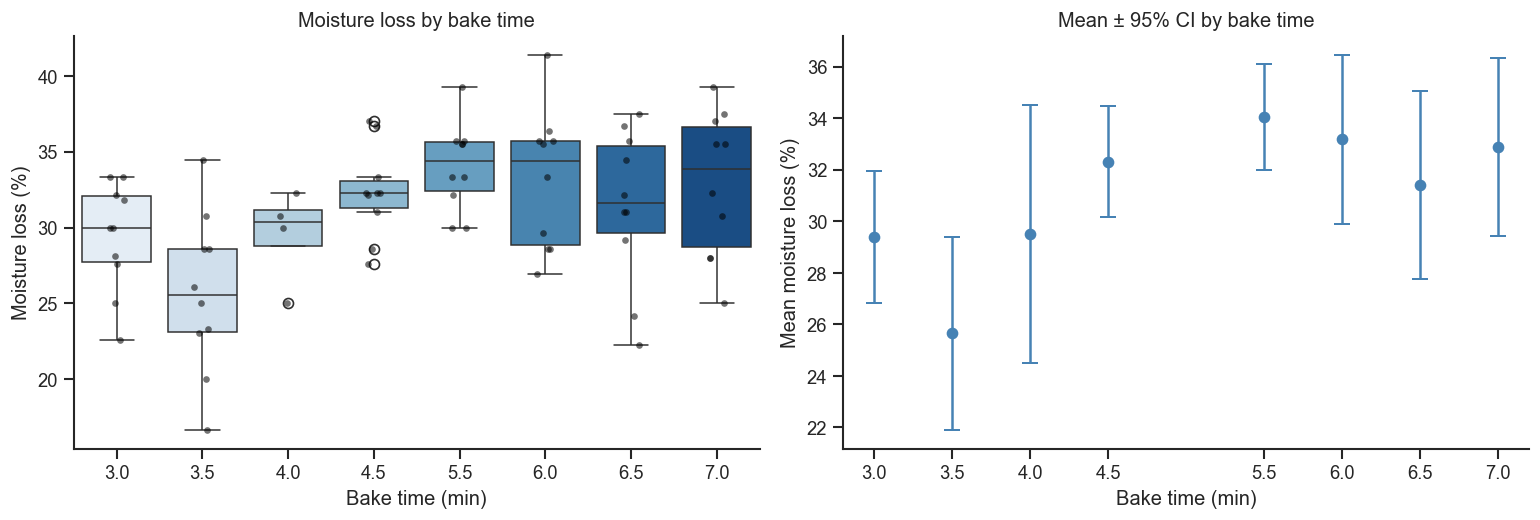

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# --- Left: box + strip plot ---
ax = axes[0]
sns.boxplot(data=df, x='Bake_time', y='Moisture_loss_pct',
            palette='Blues', linewidth=0.9, ax=ax, order=bake_times)
sns.stripplot(data=df, x='Bake_time', y='Moisture_loss_pct',
              color='black', alpha=0.55, size=4, jitter=True,
              ax=ax, order=bake_times)
ax.set_xlabel('Bake time (min)')
ax.set_ylabel('Moisture loss (%)')
ax.set_title('Moisture loss by bake time')

# --- Right: mean ± 95% CI ---
ax2 = axes[1]
for bt in bake_times:
    row = summary.loc[bt]
    ax2.errorbar(bt, row['Mean (%)'],
                 yerr=[[row['Mean (%)'] - row['95% CI lower']],
                       [row['95% CI upper'] - row['Mean (%)']]],
                 fmt='o', capsize=5, capthick=1.2, markersize=6,
                 color='steelblue', ecolor='steelblue')
ax2.set_xlabel('Bake time (min)')
ax2.set_ylabel('Mean moisture loss (%)')
ax2.set_title('Mean ± 95% CI by bake time')
ax2.set_xticks(bake_times)

sns.despine()
plt.tight_layout()
plt.show()

**Comments**: The box plot (left) shows the full distribution of moisture loss within each group the box spans the interquartile range (25th-75th percentile), the horizontal line inside is the median, and the whiskers extend to 1.5x— the IQR. The mean ± 95% CI plot (right) is more useful for comparing groups: if two confidence intervals do not overlap, the groups are very likely to be statistically significantly different. Overlapping CIs do not guarantee non-significance, but wide overlaps suggest the groups are hard to distinguish.

### 2.5 Pairwise t-Tests

We use Welch's t-test, which does not assume equal variance between groups. This is appropriate here since some groups are more variable than others.

The t-statistic is converted to a p-value using a t-distribution. A large |t| (far from zero) corresponds to a small p-value.

#### Multiple comparisons correction

With 28 tests at α = 0.05, the expected number of false positives is 28 × 0.05 = 1.4. The Bonferroni correction addresses this by requiring a raw p-value below 0.05 / 28 ≈ 0.00179 to claim significance. Equivalently, the corrected p-value is raw × 28, capped at 1.

In [6]:
pairs = list(combinations(bake_times, 2))
n_tests = len(pairs)
alpha = 0.05

results = []
for bt_a, bt_b in pairs:
    a = df.loc[df['Bake_time'] == bt_a, 'Moisture_loss_pct'].dropna().values
    b = df.loc[df['Bake_time'] == bt_b, 'Moisture_loss_pct'].dropna().values
    t_stat, p_raw = stats.ttest_ind(a, b, equal_var=False)  # Welch's
    p_bonf = min(p_raw * n_tests, 1.0)
    mean_diff = a.mean() - b.mean()
    results.append({
        'Group A (min)':   bt_a,
        'Group B (min)':   bt_b,
        'Mean A (%)':      round(a.mean(), 2),
        'Mean B (%)':      round(b.mean(), 2),
        'Diff A-B (%)':    round(mean_diff, 2),
        'SD A (%)':        round(a.std(ddof=1), 2),
        'SD B (%)':        round(b.std(ddof=1), 2),
        'n_A':             len(a),
        'n_B':             len(b),
        't-stat':          round(t_stat, 3),
        'p (raw)':         round(p_raw, 4),
        'p (Bonf)':        round(p_bonf, 4),
        'Sig (raw)':       '✓' if p_raw < alpha else '',
        'Sig (Bonf)':      '✓' if p_bonf < alpha else '',
    })

results_df = pd.DataFrame(results)
print(f"Total comparisons: {n_tests}  |  Bonferroni threshold: p < {alpha/n_tests:.5f}")
results_df

Total comparisons: 28  |  Bonferroni threshold: p < 0.00179


,Group A (min),Group B (min),Mean A (%),Mean B (%),Diff A-B (%),SD A (%),SD B (%),n_A,n_B,t-stat,p (raw),p (Bonf),Sig (raw),Sig (Bonf)
0,3.0,3.5,29.39,25.66,3.74,3.59,5.23,10,10,1.862,0.0812,1.0000,,
1,3.0,4.0,29.39,29.51,-0.11,3.59,3.15,10,4,-0.059,0.9546,1.0000,,
2,3.0,4.5,29.39,32.31,-2.92,3.59,2.99,10,10,-1.980,0.0637,1.0000,,
3,3.0,5.5,29.39,34.05,-4.66,3.59,2.88,10,10,-3.202,0.0052,0.1446,✓,
4,3.0,6.0,29.39,33.17,-3.78,3.59,4.59,10,10,-2.049,0.0562,1.0000,,
5,3.0,6.5,29.39,31.41,-2.02,3.59,5.12,10,10,-1.021,0.3223,1.0000,,
6,3.0,7.0,29.39,32.88,-3.49,3.59,4.80,10,10,-1.840,0.0836,1.0000,,
7,3.5,4.0,25.66,29.51,-3.85,5.23,3.15,10,4,-1.686,0.1244,1.0000,,
8,3.5,4.5,25.66,32.31,-6.66,5.23,2.99,10,10,-3.494,0.0035,0.0973,✓,
9,3.5,5.5,25.66,34.05,-8.39,5.23,2.88,10,10,-4.444,0.0006,0.0156,✓,✓


### 2.7 Heatmap of p-values

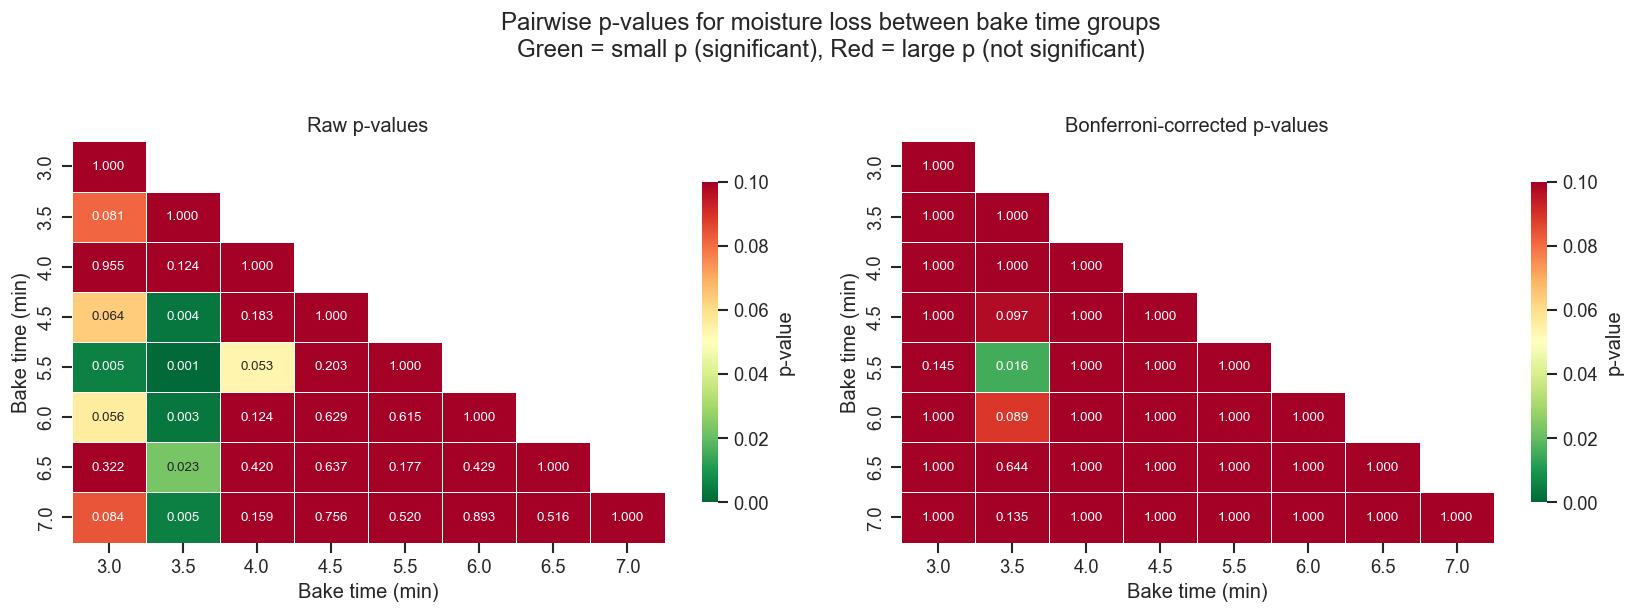

In [7]:
# Build a symmetric matrix of Bonferroni-corrected p-values
bt_labels = [str(bt) for bt in bake_times]
p_matrix = pd.DataFrame(np.nan, index=bt_labels, columns=bt_labels)
for _, row in results_df.iterrows():
    a, b = str(row['Group A (min)']), str(row['Group B (min)'])
    p_matrix.loc[a, b] = row['p (Bonf)']
    p_matrix.loc[b, a] = row['p (Bonf)']
np.fill_diagonal(p_matrix.values, 1.0)  # self-comparisons

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (p_col, title) in zip(axes, [
    ('p (raw)',  'Raw p-values'),
    ('p (Bonf)', 'Bonferroni-corrected p-values'),
]):
    mat = pd.DataFrame(np.nan, index=bt_labels, columns=bt_labels)
    for _, row in results_df.iterrows():
        a, b = str(row['Group A (min)']), str(row['Group B (min)'])
        mat.loc[a, b] = row[p_col]
        mat.loc[b, a] = row[p_col]
    np.fill_diagonal(mat.values, 1.0)

    # Mask the upper triangle
    mask = np.triu(np.ones_like(mat, dtype=bool), k=1)
    sns.heatmap(mat, mask=mask, annot=True, fmt='.3f',
                cmap='RdYlGn_r', vmin=0, vmax=0.1,
                linewidths=0.5, ax=ax, annot_kws={'size': 8},
                cbar_kws={'label': 'p-value', 'shrink': 0.8})
    ax.set_title(title)
    ax.set_xlabel('Bake time (min)')
    ax.set_ylabel('Bake time (min)')

plt.suptitle('Pairwise p-values for moisture loss between bake time groups\n'
             'Green = small p (significant), Red = large p (not significant)', y=1.02)
plt.tight_layout()
plt.show()

**Notes**: Each cell shows the p-value for the comparison between two bake times. Green cells indicate small p-values (strong evidence of a difference); red cells indicate large p-values (little evidence). The threshold for significance (0.05) sits in the yellow-green range. The right panel applies Bonferroni correction.

### 2.7 Conclusions

Within-group variability in moisture loss is large relative to between-group differences. Each bake time group shows a standard deviation of roughly 3–6 percentage points, while the differences in group means across the full 3–7 minute range span only about 5–10 percentage points. This low signal-to-noise ratio is the main reason the t-tests may fail to find significance even for groups that appear to differ. The data are insufficient to rule out chance as an explanation for the observed difference. With n = 10 chips per group, the tests have limited statistical power. To reliably detect a 5 pp difference with this level of variability, roughly 15–20 chips per group would be needed.

### 2.8 One-Way ANOVA: Does Bake Time Drive Fracture Metrics?

The pairwise t-tests above asked whether bake time groups differ in moisture loss. Here we ask a more direct question: does bake time group explain variance in the *fracture metrics themselves*?

One-way ANOVA tests whether the variance between groups is large relative to the variance withi  groups. The F-statistic is exactly this ratio:

$$F = \frac{\text{variance between group means}}{\text{mean variance within groups}}$$

A large F (and small p) means the group means are more spread out than you'd expect from within-group noise alone.

**Why ANOVA here, not just regression?**
Regression measures the linear relationship between moisture loss (a continuous variable) and fracture metrics. ANOVA treats bake time as a grouping factor and asks whether any group stands out. If ANOVA is significant but regression is not, bake time is doing something that moisture loss alone doesn't capture. If both are significant, the relationship is likely actually driven by drying.

In [8]:
# One-way ANOVA: does bake time group predict fracture metrics?
anova_metrics = [
    ('FractureEnergy_J', 'Fracture energy E_f (J)'),
    ('PeakForce_N',      'First-peak force F_peak (N)'),
    ('MaxForce_N',       'Max force F_max (N)'),
]

print(f"{'Metric':<30} {'F-stat':>8} {'p-value':>10} {'Significant (α=0.05)':>22}")
print('-' * 74)
for col, label in anova_metrics:
    groups = [g[col].dropna().values for _, g in df.groupby('Bake_time')]
    F, p = stats.f_oneway(*groups)
    sig = 'Yes' if p < 0.05 else 'No'
    print(f'{label:<30} {F:>8.3f} {p:>10.4f} {sig:>22}')

print()
print('Interpretation:')
print('  F_max is significant: bake time groups differ in max force.')
print('  E_f and F_peak are not: bake time does not reliably predict energy or first-peak force.')
print('  Compare with regression (Part 2) to see whether moisture loss explains the F_max signal.')

Metric                           F-stat    p-value   Significant (α=0.05)
--------------------------------------------------------------------------
Fracture energy E_f (J)           0.973     0.4583                     No
First-peak force F_peak (N)       1.563     0.1622                     No
Max force F_max (N)               3.371     0.0039                    Yes

Interpretation:
  F_max is significant: bake time groups differ in max force.
  E_f and F_peak are not: bake time does not reliably predict energy or first-peak force.
  Compare with regression (Part 2) to see whether moisture loss explains the F_max signal.


C:\Users\shere\AppData\Local\Temp\ipykernel_25448\1094181862.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Bake_time', y=col, ax=ax, palette='Blues', linewidth=0.8)
C:\Users\shere\AppData\Local\Temp\ipykernel_25448\1094181862.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Bake_time', y=col, ax=ax, palette='Blues', linewidth=0.8)


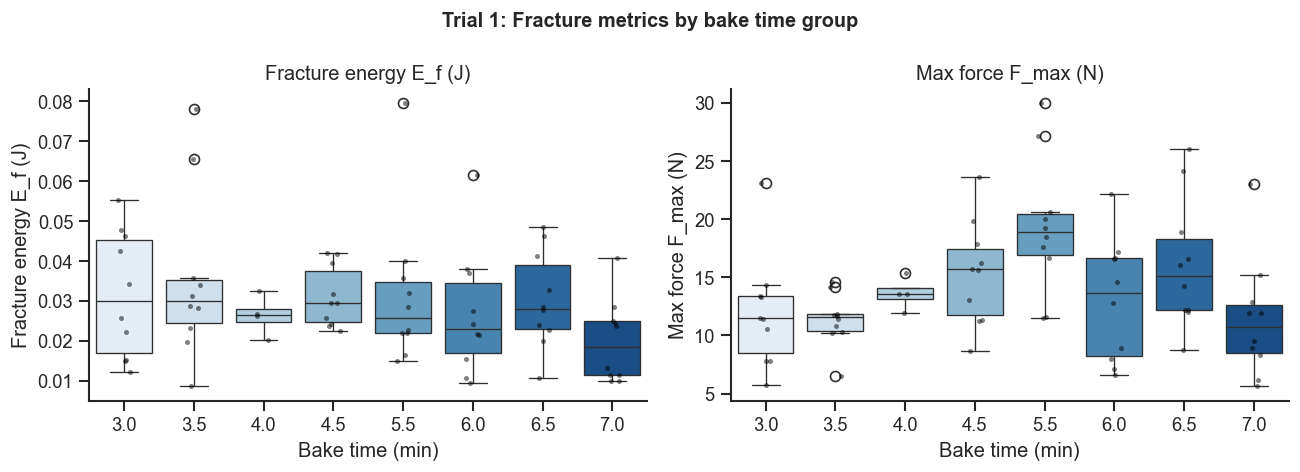

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, col, label in [
    (axes[0], 'FractureEnergy_J', 'Fracture energy E_f (J)'),
    (axes[1], 'MaxForce_N',       'Max force F_max (N)'),
]:
    sns.boxplot(data=df, x='Bake_time', y=col, ax=ax, palette='Blues', linewidth=0.8)
    sns.stripplot(data=df, x='Bake_time', y=col, ax=ax,
                  color='black', alpha=0.5, size=3, jitter=True)
    ax.set_xlabel('Bake time (min)')
    ax.set_ylabel(label)
    ax.set_title(label)
sns.despine()
plt.suptitle('Trial 1: Fracture metrics by bake time group', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---

## 3. Part 2: Fracture Mechanics Analysis

### 3.1 Context: The puffing problem

With moisture loss characterised in Part 1, we turn to the mechanical measurements collected during each fracture test: first-peak force (F_peak), maximum force (F_max), and fracture energy (E_f, area under the force-displacement curve). Each chip was fractured at a single point in the centre.

A key confound in Trial 1 is chip puffing. Chips baked at higher temperatures and longer times often developed internal steam pockets, causing the chip surface to dome. When a puffed chip broken, the punch contacts the raised bubble rather than the flat chip body. Force and energy then reflects the collapse of the bubble, not the fracture of the chip, making it an unreliable fracture metric. This effect was more severe in longer bake groups.

### 3.2 Derived Fracture Quantities

From the raw test data we compute several material properties.

| Quantity | Symbol | Definition |
|---|---|---|
| Fracture energy density | $G_c$ (J/m²) | Raw energy divided by punch cross-section area |
| Biaxial fracture stress | $\sigma_c$ (MPa) | Peak force scaled by a geometry factor from thin-plate theory |
| Elastic modulus | $E$ (MPa) | Stiffness from force-displacement slope and plate dimensions |
| Fracture toughness | $K_{Ic}$ (Pa√m) | $\sqrt{G_c \cdot E}$ — combines energy release and stiffness |

$\sigma_c$, $E$, and $K_{Ic}$ assume small deflections and linear elasticity, so they may not be completely accurate. All derived quantities scale with apparatus geometry (R, r, t) and Poisson's ratio ν = 0.3; the same formulae are applied identically in both trials. See Appendix A for sample calculations.

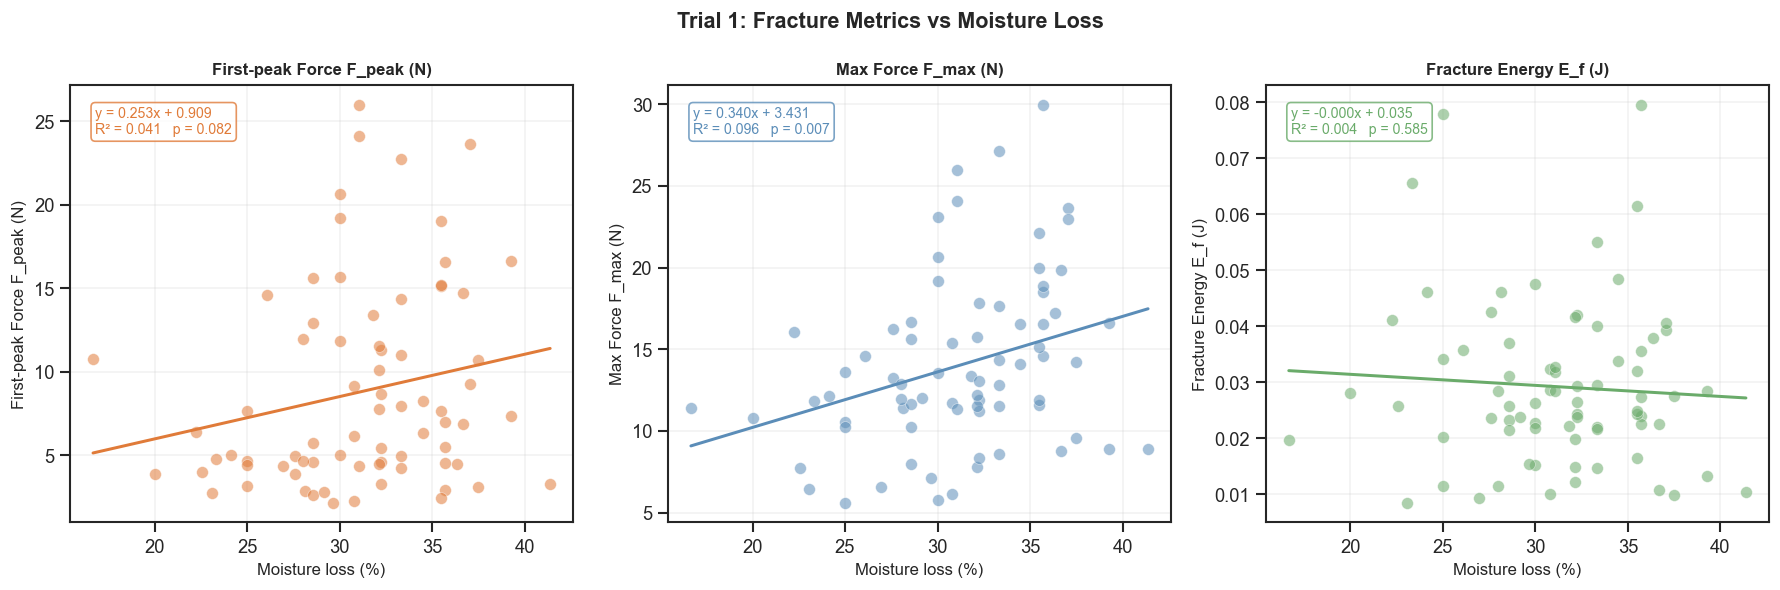

                     Metric  n    Mean     SD CV (%)    R²   slope p-value
First-peak Force F_peak (N) 74  8.8086 5.9600   67.7 0.041  0.2534  0.0823
        Max Force F_max (N) 74 14.0218 5.2470   37.4 0.096  0.3398  0.0072
    Fracture Energy E_f (J) 74  0.0292 0.0146   50.1 0.004 -0.0002  0.5849


In [10]:
metrics = [
    ('PeakForce_N',       'First-peak Force F_peak (N)',  '#e07b39'),
    ('MaxForce_N',        'Max Force F_max (N)',           '#5b8db8'),
    ('FractureEnergy_J',  'Fracture Energy E_f (J)',       '#6aab6a'),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Trial 1: Fracture Metrics vs Moisture Loss', fontsize=13, fontweight='bold')

summary_rows = []
for ax, (col, label, color) in zip(axes, metrics):
    x = df['Moisture_loss_pct'].values
    y = df[col].values
    slope, intercept, r, p, se = stats.linregress(x, y)
    r2 = r**2
    cv = y.std() / y.mean() * 100

    ax.scatter(x, y, color=color, alpha=0.55, edgecolors='white', linewidth=0.4, s=50)
    xfit = np.linspace(x.min(), x.max(), 200)
    ax.plot(xfit, slope * xfit + intercept, color=color, linewidth=1.8)
    ax.set_xlabel('Moisture loss (%)', fontsize=10)
    ax.set_ylabel(label, fontsize=10)
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.grid(alpha=0.25)

    sign = '+' if intercept >= 0 else '-'
    eq = f'y = {slope:.3f}x {sign} {abs(intercept):.3f}\nR² = {r2:.3f}   p = {p:.3f}'
    ax.text(0.05, 0.95, eq, transform=ax.transAxes, fontsize=8.5,
            verticalalignment='top', color=color,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=color, alpha=0.8))

    summary_rows.append({'Metric': label, 'n': len(y), 'Mean': f"{y.mean():.4f}", 'SD': f"{y.std():.4f}",
                          'CV (%)': f"{cv:.1f}", 'R²': f"{r2:.3f}", 'slope': f"{slope:.4f}", 'p-value': f"{p:.4f}"})

plt.tight_layout()
plt.show()

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

### 3.3 Regression Results

The regression summary for each fracture metric:

| Metric | R² | p-value | CoV | Interpretation |
|---|---|---|---|---|
| **Peak force** | 0.041 | 0.082 | ~68% | No significant moisture relationship. |
| **Fracture energy** | 0.004 | 0.585 | ~50% | No significant moisture relationship. |
| **F_max** | 0.096 | 0.007 | ~37% | Statistically significant but in the wrong direction from our intuitive understanding and the literature. (Wetter chips take more force to break?) Likely due to chip puffing: more baking = more puffing = artificially elevated forces. |

A CoV below ~15% would indicate reliable measurements. All three metrics are well above that threshold.

### 3.4 Reading ANOVA, CoV, and Regression Together

| Metric | CoV | ANOVA (bake time) | Regression (moisture) | Reading |
|---|---|---|---|---|
| **Fracture energy** | 50.4% | F=0.97, p=0.458. **No** | R²=0.004, p=0.585. **No** | H₀ not rejected, no relationship between moisture loss and fracture energy. |
| **Peak force** | 67.7% | F=1.56, p=0.162. **No** | R²=0.041, p=0.082. **No** |H₀ not rejected, no relationship between moisture loss and fracture energy. |
| **Max force** | 37.4% | F=3.37, p=0.004. **Yes** | R²=0.096, p=0.007. **Yes** | Both tests significant. However, slope is positive. If we took this at face value, this would mean wetter chips take more force to break. We think that this result was actually caused by the chip puffing we experienced. |

**Hypothesis test.** At α = 0.05, H₀ (no relationship between moisture loss and any fracture metric) is technically rejected: F_max regression reaches p = 0.007. However, R² = 0.096 and a positive slope indicate this is a puffing artifact rather than a genuine material effect. E_f, the physically meaningful metric, shows no relationship (p = 0.585). The rejection should not be interpreted as evidence that moisture drives fracture in Trial 1.

**What CoV means here.** All three CoVs are very high (37–68%), confirming the measurements are too noisy to be useful. BuE_f and F_peak show no group structure at all, meaning the noise is essentially random with respect to both bake time and moisture. F_max's ANOVA significance tells you its noise has *some* structure, but it is driven by puffing, not material properties.

### 3.5 Improvements for Trial 2

The dominant failure mode is chip puffing, a process-control problem rather than an inherent limit of the method. For Trial 2, the baking protocol was revised to suppress puffing by pressing chips during baking, and uniform 3D-printed chip geometry replaced hand-cut chips. The goal is to bring CoV down and remove the puffing artifact so that any ANOVA or regression signal reflects real material behaviour.

---

## A. Appendix: Sample Calculations

All calculations below use **Trial 2, Chip 1** as the worked example (chosen because it has complete derived quantities). The same formulas apply identically in Trial 1.

Chip 1 raw values: m_initial = 2.1 g, m_final = 1.7 g, F_peak = 23.66 N, E_f = 0.1695 J, Time_Start = 3.300 s, Time_Peak = 3.588 s.
Apparatus: R = 25 mm, r = 15 mm, t = 2 mm, crosshead speed v = 5.0 mm/s, ν = 0.3.

---

### A.1 Moisture Loss

$$\text{Moisture loss (\%)} = \frac{m_\text{initial} - m_\text{final}}{m_\text{initial}} \times 100$$

$$= \frac{2.1 - 1.7}{2.1} \times 100 = \frac{0.4}{2.1} \times 100 = \mathbf{19.05\%}$$

---

### A.2 Displacement at First Peak (δ_c)

The crosshead moves at a constant speed v = 5.0 mm/s. Displacement is time elapsed from test start to first-peak, multiplied by speed.

$$\delta_c = (t_\text{peak} - t_\text{start}) \times v = (3.588 - 3.300) \times 5.0 = 0.288 \times 5.0 = \mathbf{1.44 \text{ mm}}$$

---

### A.3 Fracture Energy Density (G_c)

The raw fracture energy E_f (area under force-displacement curve, in J) is normalised by the punch cross-sectional area to give an energy per unit area.

$$G_c = \frac{E_f}{\pi r^2} = \frac{0.1695}{\pi \times (0.015)^2} = \frac{0.1695}{7.07 \times 10^{-4}} = \mathbf{239.7 \text{ J/m}^2}$$

---

### A.4 Elastic Modulus (E)

Derived from the initial slope of the force-displacement curve, using the thin circular plate central loading formula:

$$E = \frac{F_\text{peak}}{\delta_c} \cdot \frac{3(1 - \nu^2) R^2}{4 t^3}$$

$$= \frac{23.66}{1.44 \times 10^{-3}} \cdot \frac{3(1 - 0.09)(0.025)^2}{4(0.002)^3} = 16{,}430 \times 53{,}320 \approx \mathbf{877 \text{ MPa}}$$

Note: this assumes linear elastic behaviour up to first peak. Tortilla chips are viscoelastic and this is an approximation.

---

### A.5 Biaxial Fracture Stress (σ_c)

$$\sigma_c = \frac{3 F_\text{peak}}{4 \pi t^2} \left[ (1 + \nu) \ln\!\frac{R}{r} + \frac{(1-\nu)(R^2 - r^2)}{2R^2} \right]$$

Geometry factor:

$$(1 + 0.3)\ln\!\frac{25}{15} + \frac{(0.7)(625 - 225)}{2 \times 625} = 1.3 \times 0.511 + \frac{280}{1250} = 0.664 + 0.224 = 0.888$$

$$\sigma_c = \frac{3 \times 23.66}{4\pi \times (0.002)^2} \times 0.888 = \frac{70.98}{5.03 \times 10^{-5}} \times 0.888 \approx \mathbf{1.25 \text{ MPa}}$$

---

### A.6 Fracture Toughness (K_Ic)

$$K_{Ic} = \sqrt{G_c \cdot E} = \sqrt{239.7 \times 877 \times 10^6} = \sqrt{2.10 \times 10^{11}} \approx \mathbf{459 \text{ kPa}\sqrt{\text{m}}}$$

For reference, commercial crackers and biscuits typically fall in the range 50–500 kPa√m, so this is within the expected ballpark.